In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

df=pd.read_csv("Day18_19_student_habits_performance.csv")
print("Shape:",df.shape)
display(df.head())
display(df.dtypes)
display(df.isna().sum().sort_values(ascending=False))
print("Duplicates:",df.duplicated().sum())

Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


student_id                           str
age                                int64
gender                               str
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                        str
attendance_percentage            float64
sleep_hours                      float64
diet_quality                         str
exercise_frequency                 int64
parental_education_level             str
internet_quality                     str
mental_health_rating               int64
extracurricular_participation        str
exam_score                       float64
dtype: object

parental_education_level         91
student_id                        0
gender                            0
age                               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
study_hours_per_day               0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

Duplicates: 0


EDA and Data Understanding

In [2]:
target="exam_score"
ids=[c for c in df.columns if c.lower().endswith("id") or c.lower()=="id"]
features=[c for c in df.columns if c not in ids+[target]]
num=df[features].select_dtypes(include=np.number).columns.tolist()
cat=df[features].select_dtypes(exclude=np.number).columns.tolist()

print("Numerical variables:",num)
print("Categorical variables:",cat)
display(df[num+[target]].describe().T)

for c in cat:
    print("\n",c)
    display(df[c].value_counts(dropna=False))

Numerical variables: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Categorical variables: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0



 gender


gender
Female    481
Male      477
Other      42
Name: count, dtype: int64


 part_time_job


...

parental_education_level
High School    392
Bachelor       350
Master         167
NaN             91
Name: count, dtype: int64


 internet_quality


internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64


 extracurricular_participation


extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64

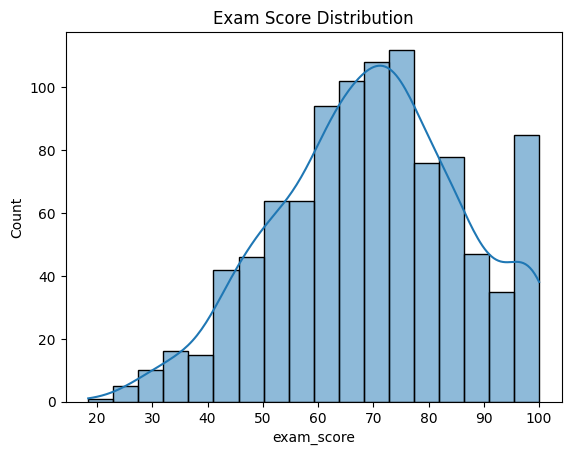

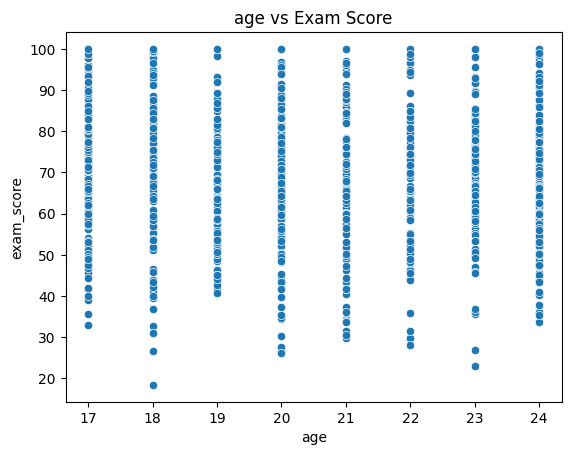

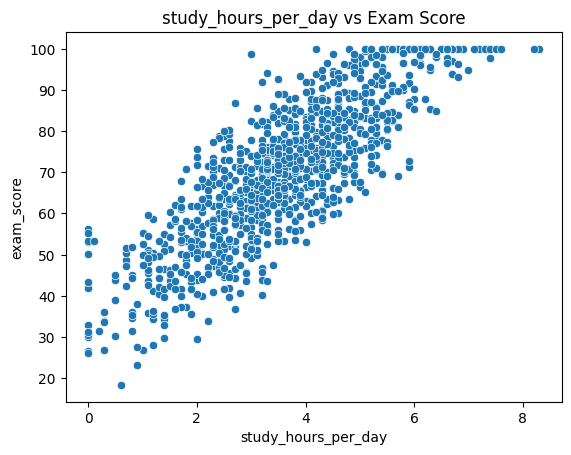

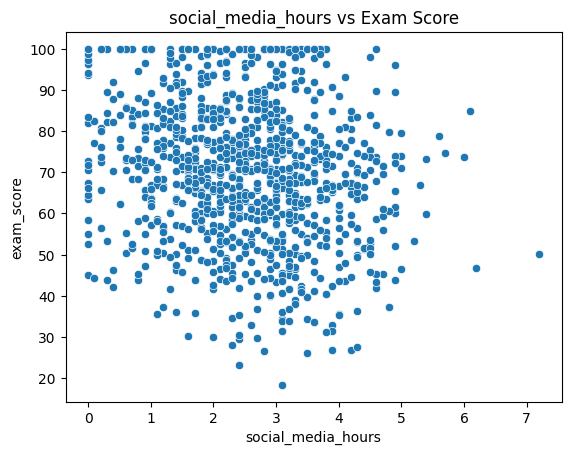

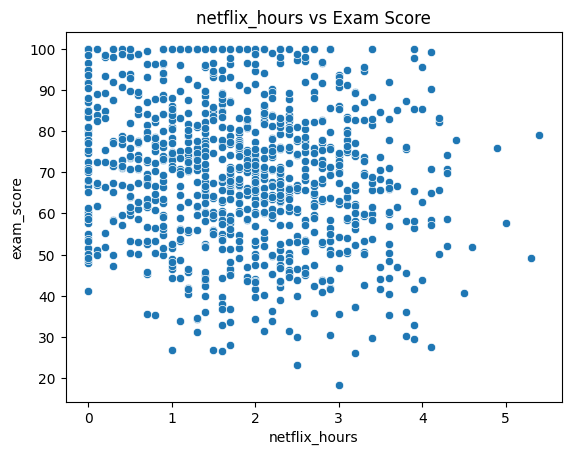

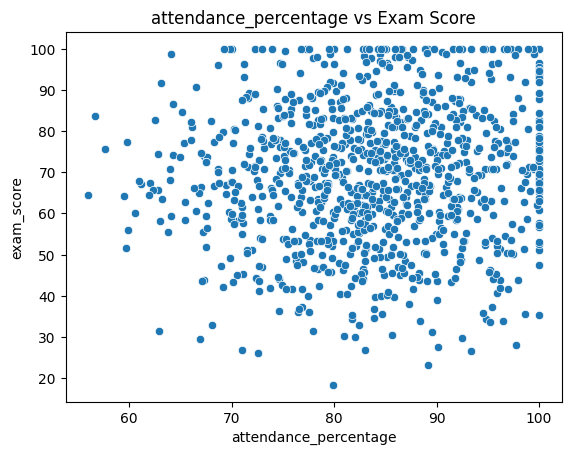

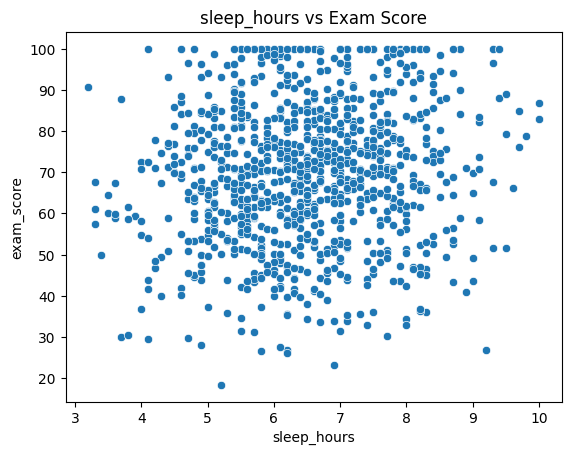

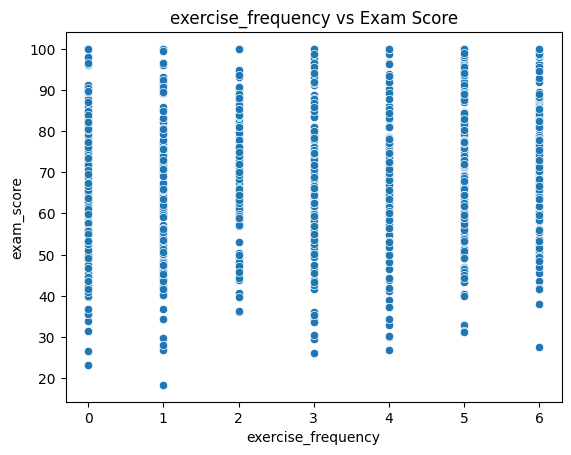

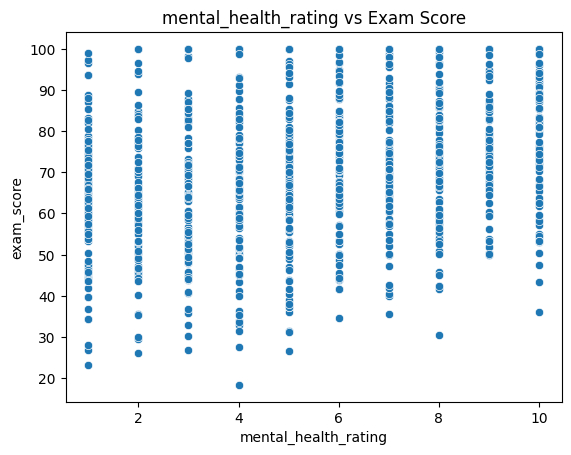

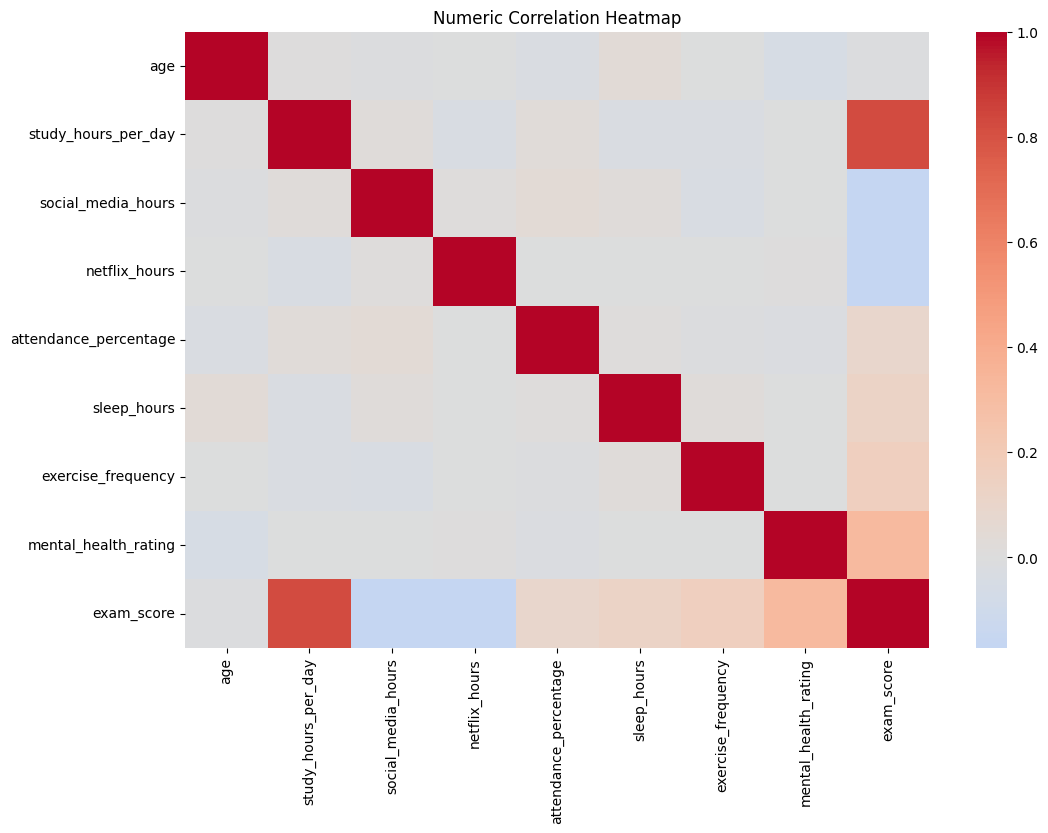

Correlation with exam_score:


exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64

In [3]:
sns.histplot(data=df,x="exam_score",kde=True)
plt.title("Exam Score Distribution")
plt.show()

for c in num:
    sns.scatterplot(data=df,x=c,y="exam_score")
    plt.title(f"{c} vs Exam Score")
    plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df[num+[target]].corr(numeric_only=True),cmap="coolwarm",center=0)
plt.title("Numeric Correlation Heatmap")
plt.show()

print("Correlation with exam_score:")
display(df[num+[target]].corr(numeric_only=True)["exam_score"].sort_values(ascending=False))

Outlier Assessment — IQR

In [4]:
out_rows=[]
for c in num:
    s=df[c].dropna()
    q1,q3=s.quantile(.25),s.quantile(.75)
    iqr=q3-q1
    lo,hi=q1-1.5*iqr,q3+1.5*iqr
    n=((s<lo)|(s>hi)).sum()
    out_rows.append([c,q1,q3,iqr,int(n)])

outlier_summary=pd.DataFrame(out_rows,columns=["Feature","Q1","Q3","IQR","Outlier_Count"])
display(outlier_summary.sort_values("Outlier_Count",ascending=False))

,Feature,Q1,Q3,IQR,Outlier_Count
1,study_hours_per_day,2.60,4.500,1.900,7
2,social_media_hours,1.70,3.300,1.600,5
3,netflix_hours,1.00,2.525,1.525,4
4,attendance_percentage,78.00,91.025,13.025,3
5,sleep_hours,5.60,7.300,1.700,2
0,age,18.75,23.000,4.250,0
6,exercise_frequency,1.00,5.000,4.000,0
7,mental_health_rating,3.00,8.000,5.000,0


Leakage-Safe Preprocessing

In [5]:
y=pd.to_numeric(df[target],errors="coerce")
valid=y.notna()
X=df.loc[valid,features].copy()
y=y.loc[valid]

num=X.select_dtypes(include=np.number).columns.tolist()
cat=X.select_dtypes(exclude=np.number).columns.tolist()

def make_preprocessor():
    return ColumnTransformer([
        ("num",Pipeline([
            ("imputer",SimpleImputer(strategy="median")),
            ("scaler",StandardScaler())
        ]),num),
        ("cat",Pipeline([
            ("imputer",SimpleImputer(strategy="most_frequent")),
            ("encoder",OneHotEncoder(handle_unknown="ignore"))
        ]),cat)
    ])

Linear Regression — Predict exam_score

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=42)

reg_model=Pipeline([
    ("preprocessor",make_preprocessor()),
    ("model",LinearRegression())
])

reg_model.fit(X_train,y_train)

train_pred=reg_model.predict(X_train)
test_pred=reg_model.predict(X_test)

reg_results=pd.DataFrame({
    "MAE":[mean_absolute_error(y_train,train_pred),mean_absolute_error(y_test,test_pred)],
    "RMSE":[np.sqrt(mean_squared_error(y_train,train_pred)),np.sqrt(mean_squared_error(y_test,test_pred))],
    "R2":[r2_score(y_train,train_pred),r2_score(y_test,test_pred)]
},index=["Train","Test"])

display(reg_results)

,MAE,RMSE,R2
Train,4.214166,5.344722,0.902108
Test,4.192343,5.150974,0.896531


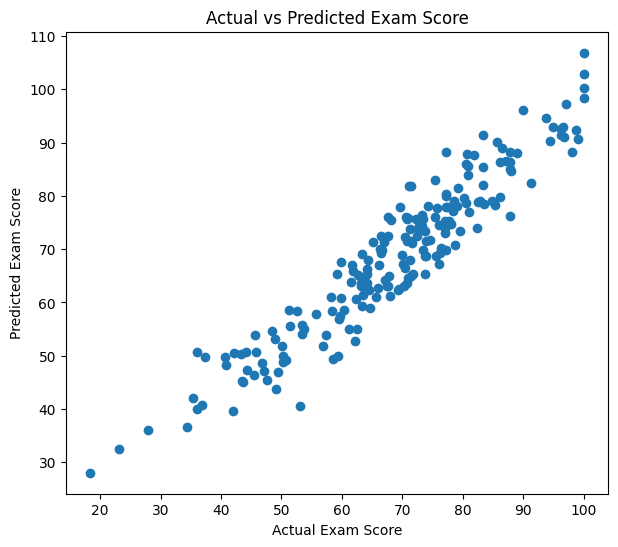

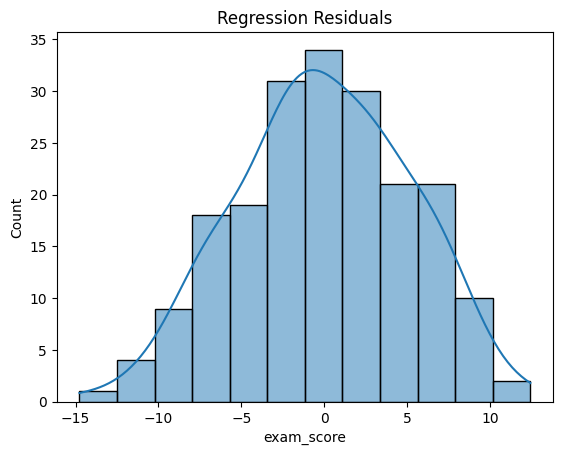

In [7]:
plt.figure(figsize=(7,6))
plt.scatter(y_test,test_pred)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score")
plt.show()

residuals=y_test-test_pred
sns.histplot(residuals,kde=True)
plt.title("Regression Residuals")
plt.show()

Classification — Pass/Fail

In [8]:
y_class=(y>=50).astype(int)

X_train_c,X_test_c,y_train_c,y_test_c=train_test_split(
    X,y_class,test_size=.20,random_state=42,stratify=y_class
)

clf_model=Pipeline([
    ("preprocessor",make_preprocessor()),
    ("model",LogisticRegression(max_iter=2000))
])

clf_model.fit(X_train_c,y_train_c)

train_class_pred=clf_model.predict(X_train_c)
test_class_pred=clf_model.predict(X_test_c)

class_results=pd.DataFrame({
    "Accuracy":[accuracy_score(y_train_c,train_class_pred),accuracy_score(y_test_c,test_class_pred)],
    "Precision":[precision_score(y_train_c,train_class_pred,zero_division=0),precision_score(y_test_c,test_class_pred,zero_division=0)],
    "Recall":[recall_score(y_train_c,train_class_pred,zero_division=0),recall_score(y_test_c,test_class_pred,zero_division=0)],
    "F1":[f1_score(y_train_c,train_class_pred,zero_division=0),f1_score(y_test_c,test_class_pred,zero_division=0)]
},index=["Train","Test"])

display(class_results)

,Accuracy,Precision,Recall,F1
Train,0.9575,0.970128,0.981295,0.975680
Test,0.9550,0.971429,0.977011,0.974212


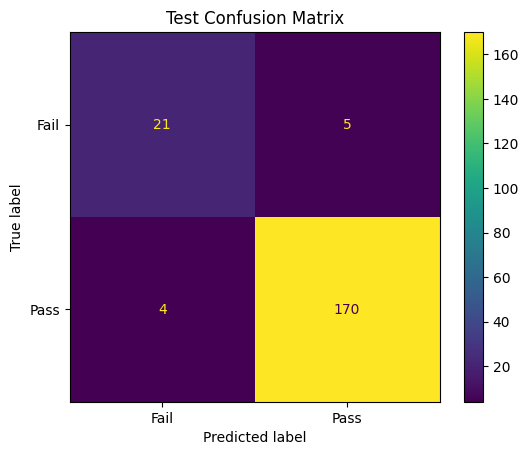

[[ 21   5]
 [  4 170]]


In [9]:
cm=confusion_matrix(y_test_c,test_class_pred)
ConfusionMatrixDisplay(cm,display_labels=["Fail","Pass"]).plot()
plt.title("Test Confusion Matrix")
plt.show()
print(cm)

Overfitting / Underfitting

In [10]:
r2_gap=reg_results.loc["Train","R2"]-reg_results.loc["Test","R2"]
f1_gap=class_results.loc["Train","F1"]-class_results.loc["Test","F1"]

print("Regression R² train-test gap:",r2_gap)
print("Classification F1 train-test gap:",f1_gap)

if r2_gap>.15 or f1_gap>.15:
    print("Possible overfitting: training performance is materially better than testing performance.")
elif reg_results.loc["Train","R2"]<.50 and reg_results.loc["Test","R2"]<.50:
    print("Possible underfitting: regression R² is low on both training and testing data.")
else:
    print("No strong evidence of severe overfitting; train/test performance is reasonably aligned.")

Regression R² train-test gap: 0.0055768197425692945
Classification F1 train-test gap: 0.0014675078191931368
No strong evidence of severe overfitting; train/test performance is reasonably aligned.
